<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>

# __Autoencoder with Python__

Estimated time needed: **60** minutes


In this lab, we will first review how to build a shallow autoencoder using the Keras functional API and the Model subclassing. Then, we will review some applications of autoencoders such as image denoising and image compression. Lastly, we will use what we have learned in the later sections to build deeper autoencoders.

As the figure shows below, when used on images, autoencoders can not only return the reconstructed image but also return a compressed version of it. The compressed data is very useful as it achieves the goal of dimensionality reduction while retaining meaningful information from the image. We will soon dive deep into how different types of autoencoders help us realize all these goals!

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/intro_pic.png" width="65%" style="vertical-align:middle;margin:30px 0px"></center>

Image credits to [Yifei Zhang](https://www.semanticscholar.org/paper/A-Better-Autoencoder-for-Image%3A-Convolutional-Zhang/b1786e74e233ac21f503f59d03f6af19a3699024?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01)


## Table of Contents

<ol>
    <li><a href="#Objectives">Objectives</a></li>
    <li>
        <a href="#Setup">Setup</a>
        <ol>
            <li><a href="#Installing-Required-Libraries">Installing Required Libraries</a></li>
            <li><a href="#Importing-Required-Libraries">Importing Required Libraries</a></li>
            <li><a href="#Defining-Helper-Functions">Defining Helper Functions</a></li>
        </ol>
    </li>
    <li><a href="#Introduction">Introduction</a></li>
    <li>
        <a href="#Shallow Autoencoders">Shallow Autoencoders</a>
        <ol>
            <li><a href="#Autoencoders using the Functional API ">Autoencoders using the Functional API </a></li>
            <li><a href="#Autoencoders using Model Subclassing">Autoencoders using Model Subclassing </a></li>
        </ol>
    </li>
    <li><a href="Applications of Autoencoders">Applications of Autoencoders</a>
        <ol>
            <li><a href="#Anomaly Detection with Auto-Encoders">Anomaly Detection with Auto-Encoders</a></li>
            <li><a href="#Denoising Autoencoders">Denoising Autoencoders</a></li>
             <li><a href="#Exercise 1">Exercise 1</a></li>
             <li><a href="#Exercise 2">Exercise 2</a></li>
        </ol>           
    </li>
    <li><a href="Deep Autoencoders">Deep Autoencoders</a>
        <ol>
            <li><a href="#Loading Images From a Directory for Autoencoders">Loading Images From a Directory for Autoencoders</a></li>
        </ol>     
    </li>      
    <li><a href="#Convolutional Autoencoders">Convolutional Autoencoders</a></li>
</ol>


## Objectives

After completing this lab, you will be able to:

 - Apply Autoencoders to real world problems 
 - Implement different autoencoder architecture
 - Train different autoencoders 


----


## Setup

For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### Installing Required Libraries

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Anaconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the following code cell.


In [1]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy numpy==1.22.3 matplotlib==3.5.1 tensorflow==2.9.0 opencv-python==4.5.5.62

# Note: If your environment doesn't support "!mamba install", use "!pip install --user"

# RESTART YOUR KERNEL AFTERWARD AS WELL

Upgrade the tensorflow and skillsnetwork library:


In [2]:
%%capture
!pip install --upgrade tensorflow
!pip install --upgrade skillsnetwork

### Importing Required Libraries

*We recommend you import all required libraries in one place (here):*


In [3]:
import os
import copy
import skillsnetwork

import numpy as np
from numpy.core.fromnumeric import reshape

import tensorflow as tf
    
import keras
from keras import layers,Input,Sequential 
from keras.layers import Dense,Flatten,Reshape,Conv2DTranspose,Conv2D
from keras.models import Model


from keras.layers import Conv2D
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

2025-04-30 08:20:47.901057: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-30 08:20:48.132956: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-30 08:20:48.138673: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-04-30 08:20:48.138704: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore 

### Defining Helper Functions


In [4]:
def plot_images(top,bottom,start=0,stop=5,reshape_x=(28,28),reshape_xhat=(28,28)):
    
    '''
    this function plots images from the start index to the stop index from two datasets
    
    '''

    n_samples=stop-start

    for i,img_index in enumerate(range(start,stop)):
        
        # Display original
        ax = plt.subplot(2, n_samples, i + 1)
        plt.imshow(top[img_index].reshape(reshape_x[0], reshape_x[1]), cmap="gray")

        if i==n_samples//2:
            plt.title("original images")

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Display reconstruction
        ax = plt.subplot(2, n_samples, i + 1 + n_samples)
        plt.imshow(bottom[img_index].reshape(reshape_xhat[0], reshape_xhat[1]), cmap="gray")


        if i==n_samples//2:
            plt.title("encoded images")

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

In [5]:
def graph_history(history, title='Log Loss and Accuracy over iterations'):

    fig = plt.figure(figsize=(16, 8))
    fig.suptitle(title)
    N_plots=len(history.history.keys())
    color_list=['b', 'r', 'g', 'c', 'm', 'y', 'k', 'w','bx','rx']
    for i,(key, items) in enumerate(history.history.items()):
        ax = fig.add_subplot(1, N_plots, i+1)
        ax.plot(items,c=color_list[i])
        ax.grid(True)
        ax.set(xlabel='iterations', title=key)

In [6]:
def add_noise(x_train, x_test, noise_factor = 0.3):
    '''
    this function adds random values from a normal distribution as noises to the data 
    
    returns the noisy datasets 
    
    '''
    noise_factor = 0.3
    x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape) 
    x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape) 

    x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.).numpy()
    x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.).numpy()
    
    return x_train_noisy,x_test_noisy

In [7]:
def plot_code(h, y, numbers=[0,1,2,3,4,5,6,7,8,9], scale=[1,1,1]):
    """
    number: list of classes to be plotted 
    scale: scale activations to plot better 
    
    """
    h=h.numpy()
    color_list=['b', 'g', 'r', 'c', 'm', 'y', 'k', 'pink','darkorange','lime']
    logic_array =np.zeros(len(y), dtype=bool)
    
    fig=plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')

    for num, color in zip(numbers, color_list):
        logic_array = (y==num)
        plt.scatter(scale[0]*h[logic_array,0],scale[1]*h[logic_array,1],scale[2]*h[logic_array,2],c=color, label=num)
 
    plt.title("3D output of encoder, colored by digits")
    plt.legend(loc=[1.1,0.3])
    plt.show()

In [8]:
def avg(shape, dtype=None):
    grad = np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
        ]).reshape((3, 3, 1, 1))/9
    
    assert grad.shape == shape
    return keras.backend.variable(grad, dtype='float32')

a_conv = layers.Conv2D(filters=1,
                       kernel_size=3,
                       kernel_initializer=avg,
                       strides=1,
                       padding='same')




In [9]:
def display_auto(Xiter,n=1,B=1):

    """
    This function displays the ouput of an autoencder 
    Returns:  void images 
    Args: 
    Xiter:image_dataset_from_directory object converted to iterator 
    n:sample within batch 
    B: batch number 
    """

    for b in range(B):    
        x = next(Xiter)
    
        plt.imshow(x[1].numpy()[n,:,:,0],cmap="gray")
        plt.title("input")
        plt.show()
        plt.imshow(x[0].numpy()[n,:,:,0],cmap="gray")
        plt.title("output")
        plt.show()

## Introduction


An autoencoder is a neural network that minimizes the difference between the input and the output. The network has two parts: the **encoder** part which outputs the code $\textbf{Z}$ using the message $\textbf{X}$ such that $\textbf{Z} = \textbf{E(X)}$. The code $\textbf{Z}$ is then passed along to reconstruct the message $\textbf{X}$, and the **decoder** is the second part does the reconstruction, which produces $\hat{\textbf{X}}= \textbf{D(Z)}$.

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/flow.png" width="60%" style="vertical-align:middle;margin:50px 0px"></center>

In general $\textbf{D(E(X))} = \hat{\textbf{X}}$ such that $\hat{\textbf{X}}$ is an approximation of $\textbf{X}$. This forces the model to learn useful properties of the data, which would be useful in applications such as image enhancement and outlier detection. 


自编码器（Autoencoder）是一种神经网络，它的目标是**最小化输入与输出之间的差异**。  
该网络由两个部分组成：

- 第一部分是**编码器（encoder）**，它接受输入信息 \(\textbf{X}\)，并生成一个压缩后的表示 \(\textbf{Z}\)，即  
  \[
  \textbf{Z} = \textbf{E(X)}
  \]

- 然后将 \(\textbf{Z}\) 传递给**解码器（decoder）**，解码器用于还原原始信息，产生重构结果 \(\hat{\textbf{X}}\)，即  
  \[
  \hat{\textbf{X}} = \textbf{D(Z)}
  \]

<div align="center">
  <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/flow.png" width="60%">
</div>

通常来说，自编码器满足：
\[
\textbf{D(E(X))} = \hat{\textbf{X}}
\]
其中 \(\hat{\textbf{X}}\) 是对 \(\textbf{X}\) 的近似重构。

这种结构迫使模型学习输入数据的有用特征，使其在诸如**图像增强**、**异常检测**等应用中非常有价值。

## Shallow Autoencoders 

They are the simplest autoencoders, which typically consist of a one-layer encoder followed by a one-layer decoder. The encoder can have an activation function or not. Similarly, the decoder can have a real output or a bounded output, for example, between 0 and 1.

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/shallow_model.png" width="45%" style="vertical-align:middle;margin:30px 0px"></center>


Let's use the MNIST data from `keras.datasets` as a beginning example:

## 浅层自编码器（Shallow Autoencoders）

浅层自编码器是最简单的一类自编码器，通常由**单层编码器**和**单层解码器**组成。  
编码器部分可以使用激活函数，也可以不使用；  
同样，解码器的输出可以是**真实数值**，也可以是**有界输出**，例如限制在 0 到 1 之间。

<div align="center">
  <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/shallow_model.png" width="45%">
</div>

接下来，我们将以 `keras.datasets` 中的 **MNIST 手写数字数据集**作为入门示例，来构建一个浅层自编码器。

In [10]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) =keras.datasets.mnist.load_data()


x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

11490434/11490434 [==============================] - 0s 0us/step
(60000, 784)
(10000, 784)


Here we introduce two ways to build shallow autoencoders in Keras, one is using the **Keras functional API**, and the other one is **subclassing the Keras Model class**. 


### Autoencoders using the Functional API 

The functional interface **uses the layers as functions**, taking a tensor as input and outputting a tensor instead of stacking layers on top of one another (like the Sequential class in Keras). By doing so, your way of building up the model layers is **more flexible** in the sense that your **model can take inputs from multiple paths and then add the tensors together at some point**.

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/functional_API.png" width="30%" style="vertical-align:middle;margin:0px 0px"></center>

### 使用 Functional API 构建自编码器

Functional API（函数式接口）是 Keras 中构建模型的一种方式，它将**层视为函数**，接受一个张量作为输入，输出一个新的张量，  
这与传统的 `Sequential` 类（通过逐层堆叠构建模型）不同。

这种方式的优点是：构建模型时更加**灵活**，你可以创建**多输入、多路径、多分支**的复杂结构，  
并在某个位置将多个张量合并，例如进行拼接（concatenate）或相加（add）等操作。

<div align="center">
  <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/functional_API.png" width="30%">
</div>

We create an input object, ```input_img```, which allows us to input tensors into our model object; as each image is 784 dimensional, the input shape is (784, ).


In [11]:
input_img=Input(shape=(784,))

We create an encoder layer using a Dense layer and the Relu activation. The encoding dimension will be the output dimension of the Dense layer. We also call the object ``input_img`` to specify the input of the encoding layer.


In [12]:
encoding_dim=36
encoder = Dense(encoding_dim, activation='relu')(input_img)

2025-04-30 08:20:51.552418: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2025-04-30 08:20:51.552496: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2025-04-30 08:20:51.552560: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (jupyterlab-sunyushen): /proc/driver/nvidia/version does not exist
2025-04-30 08:20:51.553006: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


The output dimension of the image. We create a decoding layer using a Dense layer; as the image values are between 0 to 1, we use the sigmoid activation for the output. We also call the object ```encoder``` to specify the input of the decoding layer, and this layer can also be linear.


In [13]:
decoder=Dense(784,activation='sigmoid')(encoder)

We combine the encoder and decoder using the model class for training and inference, specifying the input ```input_img``` and output  ```decoder```


In [14]:
autoencoder =Model(input_img, decoder)

We compile the model using the adam optimizer and the cross entropy loss, and you can also use the mean square error as the loss function.


In [15]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

We now fit the model; if you recall, in the supervised case, the first two inputs are (y_true, y_pred), where y_true are the ground truth values, and y_pred is the predicted value. As the autoencoder tries to replicate the input, y_true and y_pred are the input x, similarly for the validation data. The rest of the parameters behave similarly. 


In [16]:
history=autoencoder.fit(x_train, x_train,
                epochs=25,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/25
235/235 [==============================] - 7s 29ms/step - loss: 0.2716 - val_loss: 0.1860
Epoch 2/25
235/235 [==============================] - 7s 30ms/step - loss: 0.1666 - val_loss: 0.1486
Epoch 3/25
235/235 [==============================] - 6s 27ms/step - loss: 0.1394 - val_loss: 0.1289
Epoch 4/25
235/235 [==============================] - 6s 26ms/step - loss: 0.1243 - val_loss: 0.1172
Epoch 5/25
235/235 [==============================] - 7s 28ms/step - loss: 0.1143 - val_loss: 0.1088
Epoch 6/25
235/235 [==============================] - 6s 27ms/step - loss: 0.1071 - val_loss: 0.1027
Epoch 7/25
235/235 [==============================] - 6s 27ms/step - loss: 0.1017 - val_loss: 0.0981
Epoch 8/25
235/235 [==============================] - 7s 28ms/step - loss: 0.0977 - val_loss: 0.0950
Epoch 9/25
235/235 [==============================] - 7s 29ms/step - loss: 0.0949 - val_loss: 0.0927
Epoch 10/25
235/235 [==============================] - 6s 28ms/step - loss: 0.0930 - val_lo

We can plot the loss for each iteration:


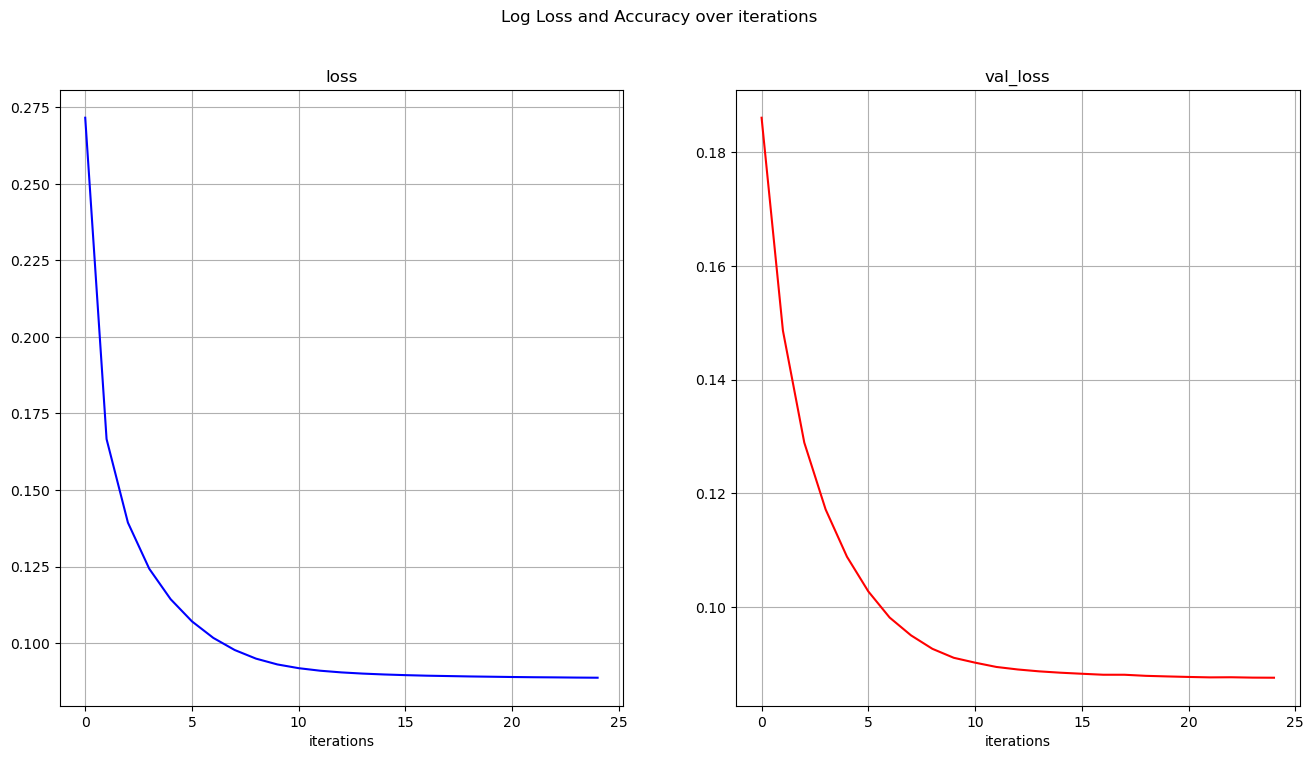

In [17]:
graph_history(history, title='Log Loss and Accuracy over iterations')

We see that the loss is lower; furthermore, the training data is similar to the testing data. This suggests the Autoencoder does well at modeling the data.


We can make a prediction using the method ```predict```


In [18]:
xhat=autoencoder.predict(x_test)

313/313 [==============================] - 1s 2ms/step


We can compare the output of the autoencoder with the original input. We see they are pretty similar:


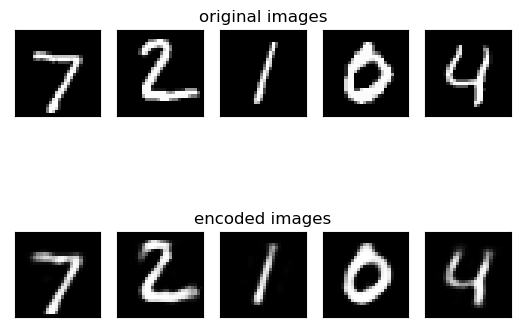

In [19]:
plot_images(x_test,xhat,start=0,stop=5)

### Autoencoders using Model Subclassing

Keras also provides an object-oriented approach to creating models, where we can subclass the `keras.Model` class to have our own class of Autoencoder models inherit or override the properties and methods of `keras.Model`. This subclassing approach **helps with reusability and allows you to represent the models you want to create as classes**. 

It's easier to use model subclassing to build autoencoders with the following boilerplate. Let's create an ```Autoencoder``` class using the `Model` class from `keras.models` as the parent class.

### 使用 Model 子类化（Model Subclassing）构建自编码器

Keras 还提供了面向对象的方式来构建模型，我们可以通过**继承 `keras.Model` 类**，定义属于我们自己的自编码器模型类。  
这种子类化（subclassing）方式可以**继承或重写 `keras.Model` 的属性和方法**，从而构建更灵活、可扩展的模型结构。

使用子类化的优势在于：

- 更易于**代码复用**；  
- 可以将模型表示为一个**完整的 Python 类**，增强代码的组织性和可维护性；  
- 特别适合需要自定义 `call` 方法、或在训练/推理过程中加入逻辑控制的复杂模型。

---

我们将使用下面的模板来构建自编码器。接下来，让我们通过继承 `keras.models.Model`，创建一个名为 `Autoencoder` 的类。

In [ ]:
class Autoencoder(tf.keras.Model):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim   
        self.encoder = Dense(latent_dim, activation='relu')
        self.decoder = Dense(784, activation='sigmoid')

    def call(self, x):
        
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

```latent_dim``` is the size of the input, and the encoder is  given by 

```encoder = tf.keras.Sequential([layers.Dense(latent_dim, activation='relu')])```

The decoder is given by:

```decoder = tf.keras.Sequential([layers.Dense(784, activation='sigmoid')])```

The method ```call``` will make a prediction and will be called when the method ```predict``` is called.


`latent_dim` 表示潜在空间的维度（即编码后的表示大小）。编码器（encoder）定义如下：

```python
encoder = tf.keras.Sequential([layers.Dense(latent_dim, activation='relu')])
```

解码器（decoder）定义如下：

```python
decoder = tf.keras.Sequential([layers.Dense(784, activation='sigmoid')])
```

其中：
- 编码器将输入压缩到维度为 `latent_dim` 的隐藏表示；
- 解码器将其还原为 784 维（适用于 MNIST 图像的 28×28 像素），使用 `sigmoid` 激活确保输出值在 0 到 1 之间。

`call` 方法用于**执行前向传播预测**，当我们调用模型的 `predict` 方法时，内部就会自动调用 `call` 方法。

With subclassing, we can now create an ```autoencoder``` instance and the only parameter that needs to be specified is the ```encoding_dim```.


In [21]:
encoding_dim=36
autoencoder = Autoencoder(encoding_dim)

The `autoencoder` instance created will not only have the attributes and methods defined within the `autoencoder` class but also inherits all the attributes of the `Model` class.


All the steps are the same as above to fit the model and make a prediction:


Epoch 1/25
235/235 [==============================] - 7s 28ms/step - loss: 0.2700 - val_loss: 0.1859
Epoch 2/25
235/235 [==============================] - 6s 27ms/step - loss: 0.1672 - val_loss: 0.1486
Epoch 3/25
235/235 [==============================] - 7s 29ms/step - loss: 0.1392 - val_loss: 0.1289
Epoch 4/25
235/235 [==============================] - 7s 28ms/step - loss: 0.1238 - val_loss: 0.1164
Epoch 5/25
235/235 [==============================] - 7s 31ms/step - loss: 0.1132 - val_loss: 0.1077
Epoch 6/25
235/235 [==============================] - 8s 34ms/step - loss: 0.1058 - val_loss: 0.1016
Epoch 7/25
235/235 [==============================] - 7s 28ms/step - loss: 0.1006 - val_loss: 0.0975
Epoch 8/25
235/235 [==============================] - 7s 30ms/step - loss: 0.0970 - val_loss: 0.0944
Epoch 9/25
235/235 [==============================] - 7s 30ms/step - loss: 0.0944 - val_loss: 0.0923
Epoch 10/25
235/235 [==============================] - 7s 30ms/step - loss: 0.0926 - val_lo

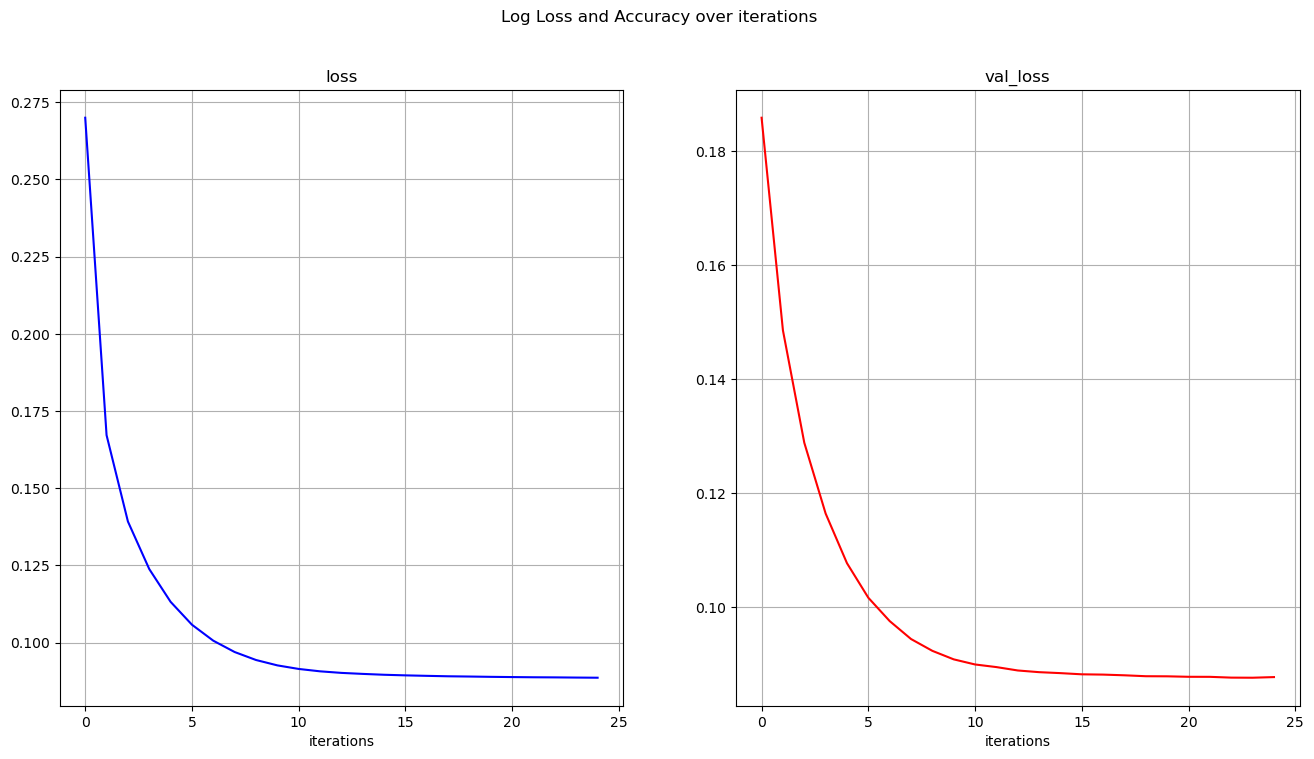

In [22]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history=autoencoder.fit(x_train, x_train,epochs=25,batch_size=256,shuffle=True,validation_data=(x_test, x_test))
graph_history(history, title='Log Loss and Accuracy over iterations')

Let's compare the images reconstructed by the trained autoencoder and the original image:


313/313 [==============================] - 1s 2ms/step


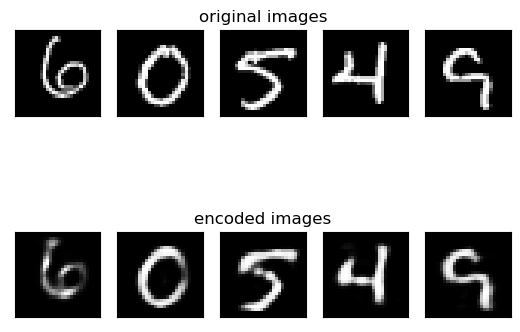

In [23]:
xhat=autoencoder.predict(x_test)
plot_images(x_test,xhat,start=100,stop=105)

We can also generate the output of the encoder by calling the method ```encoder```, which returns the activation of the encoder layer:


In [24]:
h=autoencoder.encoder(x_test)
h.shape

TensorShape([10000, 36])

Since the output dimension of the `encoder` layer is 36, we will need to reshape it to $6\times 6$ in order to plot it as images:


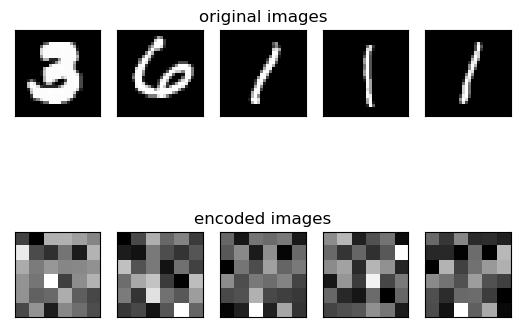

In [25]:
plot_images(x_test, h.numpy(),start=200,stop=205,reshape_x=(28,28),reshape_xhat=(6,6))

Should you use the Keras functional API to create a new model, or just subclass the Model class directly? In general, the functional API is higher-level, easier, and safer, and has a number of features that subclassed models do not support.

However, Model subclassing provides greater flexibility when building models that are not easily expressible as directed acyclic graphs of layers. For example, you could not implement a Tree-RNN with the functional API and would have to subclass the Model directly.

As a last note, choosing between the functional API or Model subclassing isn't a binary decision that restricts you into one category of models. **All models in the `tf.keras` API can interact with each other, whether they're Sequential models, functional models, or subclassed models that are written from scratch!**

你应该使用 Keras 的函数式 API 创建新模型，还是直接继承 `Model` 类进行子类化？一般来说，**函数式 API 更高级、更容易使用、更安全**，并且支持一些子类化模型不具备的功能。

不过，当你需要构建的模型**不能轻易表示为有向无环图（DAG）结构的层**时，子类化 `Model` 会提供更大的灵活性。例如，如果你想实现一棵树结构的 RNN（Tree-RNN），就无法用函数式 API 实现，必须通过子类化来完成。

最后需要注意的是，**选择函数式 API 或子类化模型不是非此即彼的选择**——`tf.keras` 中的所有模型（无论是 `Sequential` 模型、函数式模型还是从零构建的子类模型）都是兼容的，可以相互组合与交互使用。


Now you know how an autoencoder is constructed and how it works, let's see some real-world applications of autoencoders!


## Applications of Autoencoders


### Anomaly Detection with Autoencoders
Due to the autoencoder architecture (encoder + decoder), autoencoders are forced to learn representations of the images. As a result, only data samples with a similar distribution can be reconstructed with fidelity. This means a high reconstruction loss can be interpreted and used as a method to detect anomalous samples within the data.

Consider the last example. We can find anomalies of the data as follows:

First, we calculate the loss between the predicted samples and the original data. Samples reconstructed with the highest error values (losses) are the anomalies. 

### 使用自编码器进行异常检测

由于自编码器的架构（编码器 + 解码器），它被迫学习图像的表示形式。因此，**只有与训练数据分布相似的数据样本才能被高质量地重建**。这意味着，**高重建损失（reconstruction loss）可以被用作识别数据中异常样本的方法**。

以前面的示例为例，我们可以如下方式找出异常：

首先，计算模型重建后的样本与原始数据之间的损失。**重建误差（损失）最高的样本就被视为异常数据。**



We caculate the loss for each of the samples: 


In [26]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [27]:
loss=[bce(x, x_s).numpy() for x, x_s in zip (x_test,xhat)]

Let's sort the losses with **np.argsort** and then use **np.flip** to flip the order of the indexes so that the losses are sorted in descending order:


In [28]:
indexs=np.flip(np.argsort(loss))

We plot the samples with the top ten losses:


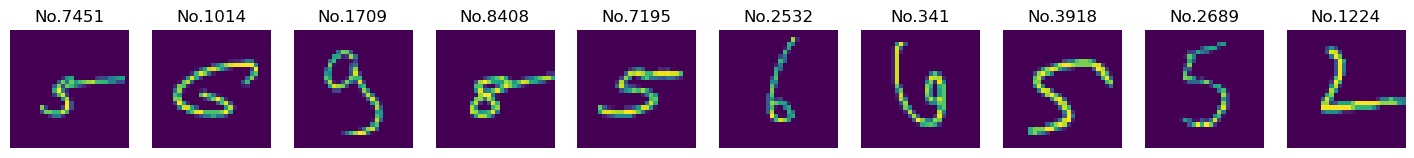

In [29]:
plt.figure(figsize=(18,3))
for i, index in enumerate(indexs[0:10]):

    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[index].reshape(28,28))
    plt.title(f"No.{index}")
    plt.axis("off")

### Denoising Autoencoders

We can also use Autoencoders for denoising. The following figure illustrates what we would like a denoising autoencoder to achieve:

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/denoising.png" width="40%" style="vertical-align:middle;margin:15px 0px"></center>


Let's first add some artificial noises to our digit dataset using the helper function **add_noise**.


In [30]:
x_train_noisy,x_test_noisy= add_noise(x_train, x_test,noise_factor = 0.4)

We can display the training images before and after adding the noises:


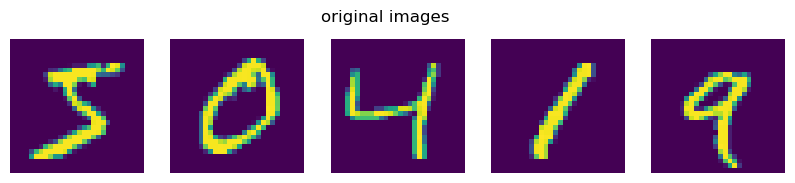

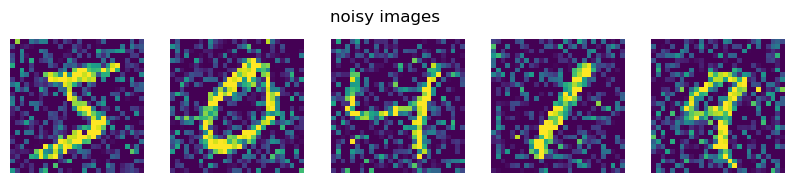

In [31]:
fig1 = plt.figure(figsize=(10,2))
fig1.suptitle("original images")
fig2 = plt.figure(figsize=(10,2))
fig2.suptitle("noisy images")

for i, img_index in enumerate(range(5)):
    ax1 = fig1.add_subplot(1, 5, i+1)
    ax1.imshow(x_train[img_index].reshape((28,28)))
    ax1.axis("off")
    ax2 = fig2.add_subplot(1, 5, i+1)
    ax2.imshow(x_train_noisy[img_index].reshape((28,28)))
    ax2.axis("off")

One way to build a **denoising Autoencoder** is to make the encoding dimension larger than the input dimension; Here, we create an ```autoencoder``` object with an encoding dimension **two times** the input dimension:

构建**去噪自编码器（denoising autoencoder）**的一种方式是：让编码维度**大于**输入维度。这样，模型在学习压缩和重建的过程中，会被迫保留输入中的主要结构信息，同时丢弃噪声。

在这里，我们创建一个 `autoencoder` 对象，使其编码维度为**输入维度的两倍**：
也就是说，模型在编码阶段映射到一个更高维度的空间，从而提高对原始信息的保留能力，有助于重建干净的数据版本，即实现“去噪”的效果。



In [32]:
encoding_dim=2*x_test.shape[1]
autoencoder = Autoencoder(encoding_dim)

We fit the model, for the fit method (y_true, y_pred), is the noisy data $x_{noisy}$ is the ground truth values, and y_pred is x_train the regular data $x$. The assumption is that where $x_{noisy}$ is a copy of $x$ with some form of noise. Training forces the encoder and decoder to learn the structure of the data implicitly.

我们训练模型时，对于 `fit` 方法中的参数 `(y_true, y_pred)`，其中的 **真实值 y\_true 是加入噪声后的数据 \$x\_{noisy}\$**，而预测值 y\_pred 是原始的干净数据 \$x\_{train}\$。这个过程的假设是：\$x\_{noisy}\$ 是在原始数据 \$x\$ 上加入某种形式噪声后得到的副本。

通过这样的训练方式，**模型被迫在编码器和解码器之间隐式地学习数据的结构**，以便在输入是噪声数据的情况下，依然能还原出干净的原始数据。


Epoch 1/25
235/235 [==============================] - 36s 150ms/step - loss: 0.1450 - val_loss: 0.0960
Epoch 2/25
235/235 [==============================] - 34s 145ms/step - loss: 0.0914 - val_loss: 0.0874
Epoch 3/25
235/235 [==============================] - 35s 150ms/step - loss: 0.0862 - val_loss: 0.0850
Epoch 4/25
235/235 [==============================] - 34s 147ms/step - loss: 0.0841 - val_loss: 0.0836
Epoch 5/25
235/235 [==============================] - 36s 154ms/step - loss: 0.0828 - val_loss: 0.0827
Epoch 6/25
235/235 [==============================] - 34s 145ms/step - loss: 0.0818 - val_loss: 0.0821
Epoch 7/25
235/235 [==============================] - 35s 148ms/step - loss: 0.0810 - val_loss: 0.0816
Epoch 8/25
235/235 [==============================] - 33s 143ms/step - loss: 0.0804 - val_loss: 0.0812
Epoch 9/25
235/235 [==============================] - 35s 150ms/step - loss: 0.0798 - val_loss: 0.0809
Epoch 10/25
235/235 [==============================] - 34s 144ms/step - l

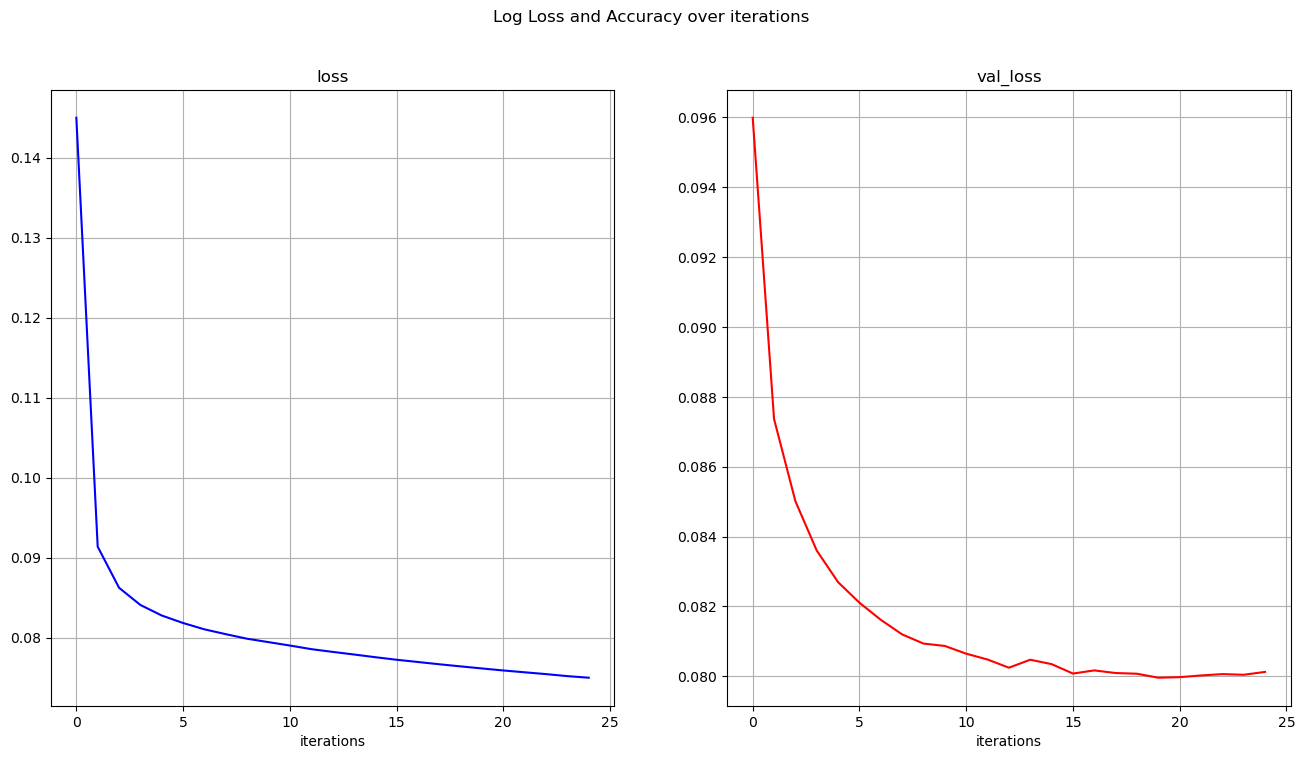

In [33]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history=autoencoder.fit(x_train_noisy , x_train,epochs=25,batch_size=256,shuffle=True,validation_data=(x_test_noisy, x_test))
graph_history(history, title='Log Loss and Accuracy over iterations')
xhat=autoencoder.predict(x_test)

Now we plot the images, and we can see that most of the noises are gone:


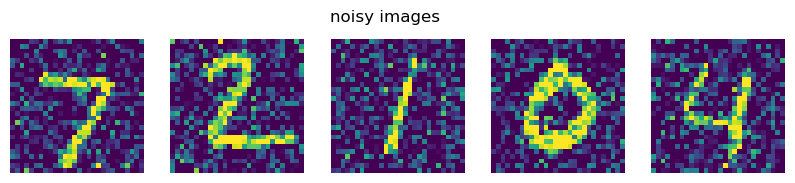

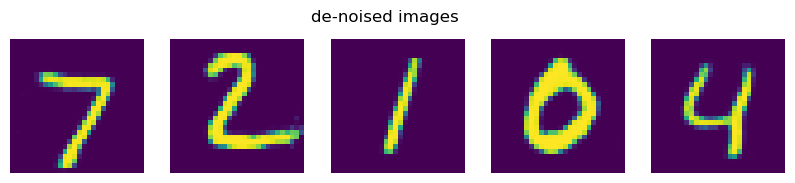

In [34]:
fig1 = plt.figure(figsize=(10,2))
fig1.suptitle("noisy images")
fig2 = plt.figure(figsize=(10,2))
fig2.suptitle("de-noised images")

for i, img_index in enumerate(range(5)):
    ax1 = fig1.add_subplot(1, 5, i+1)
    ax1.imshow(x_test_noisy[img_index].reshape((28,28)))
    ax1.axis("off")
    ax2 = fig2.add_subplot(1, 5, i+1)
    ax2.imshow(xhat[img_index].reshape((28,28)))
    ax2.axis("off")

### Exercise 1 
In this exercise, you will use the encoder part of an Autoencoder for low-dimensional data visualization. 

- Create an autocoder using the class `Autoencoder`, with latent dimension of 3; 
- Fit the autoencoder model using the training set `x_train` and validate using the test set `x_test`; 
- Apply the `.encoder` method of the autoencoder on the test set `x_test`;
- Display the output using the **plot_code** helper function.


In [35]:
autoencoder = Autoencoder(3)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history=autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))
h=autoencoder.encoder(x_test)

SyntaxError: invalid syntax (154597355.py, line 3)

<details>
    <summary>Click here for Solution</summary>

```python
autoencoder = Autoencoder(3)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history=autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))
h=autoencoder.encoder(x_test)
```

</details>


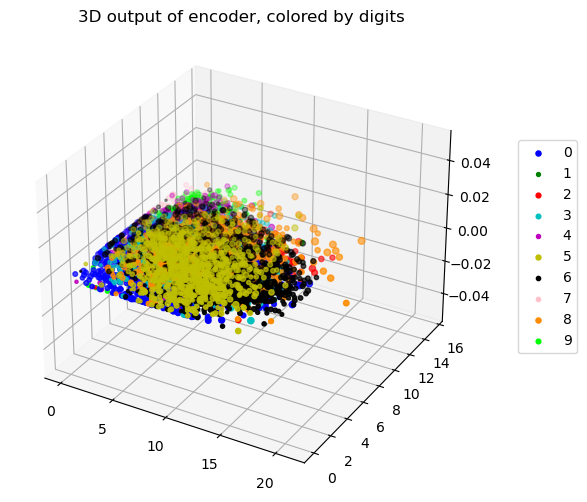

In [36]:
plot_code(h,y_test)

### Exercise 2


In this exercise, you will work with a different dataset, which is the fashion MNIST dataset downloaded from Keras. You will use an autoencoder to try to reconstruct the images and analyze the results.


In [37]:
(x_train, y_train), (x_test,y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print(x_train.shape)

4422102/4422102 [==============================] - 0s 0us/step
(60000, 28, 28)


Let's flatten the training and validation data and pass it to the Autoencoder:


In [38]:
x_temp=layers.Flatten()(x_train)
x_temp_test=layers.Flatten()(x_test)
x_temp.shape, x_temp_test.shape

(TensorShape([60000, 784]), TensorShape([10000, 784]))

In [39]:
encoding_dim=3
autoencoder = Autoencoder(encoding_dim)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history=autoencoder.fit(x_temp,x_temp,epochs=25,batch_size=256,shuffle=True,validation_data=(x_temp_test,x_temp_test))

Epoch 1/25
235/235 [==============================] - 7s 28ms/step - loss: 0.5084 - val_loss: 0.4246
Epoch 2/25
235/235 [==============================] - 7s 28ms/step - loss: 0.4013 - val_loss: 0.3932
Epoch 3/25
235/235 [==============================] - 7s 31ms/step - loss: 0.3876 - val_loss: 0.3858
Epoch 4/25
235/235 [==============================] - 7s 29ms/step - loss: 0.3818 - val_loss: 0.3813
Epoch 5/25
235/235 [==============================] - 7s 29ms/step - loss: 0.3778 - val_loss: 0.3778
Epoch 6/25
235/235 [==============================] - 6s 27ms/step - loss: 0.3746 - val_loss: 0.3750
Epoch 7/25
235/235 [==============================] - 6s 28ms/step - loss: 0.3719 - val_loss: 0.3725
Epoch 8/25
235/235 [==============================] - 7s 28ms/step - loss: 0.3696 - val_loss: 0.3704
Epoch 9/25
235/235 [==============================] - 7s 28ms/step - loss: 0.3676 - val_loss: 0.3684
Epoch 10/25
235/235 [==============================] - 6s 27ms/step - loss: 0.3658 - val_lo

Looking at the output, we see the autoencoder can't reconstruct the data very well as it's too complex; Therefore, we need a better approach to represent more complex data.


313/313 [==============================] - 1s 2ms/step


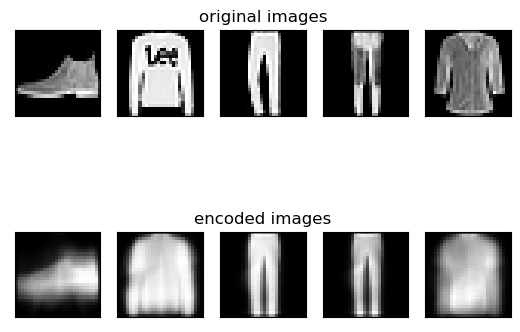

In [40]:
xhat=autoencoder.predict(x_temp_test)
plot_images(x_test,xhat,start=0,stop=5)

## Deep Autoencoders 


Like deep neural networks, adding more layers to the encoder and decoder will grant your autoencoders more representational power, allowing you to solve increasingly complex problems. For example, the reconstructed images of the fashion MNIST dataset plotted above did not retain enough features of the original images, so people will instantly recognize a shoe by looking at the first reconstructed image. Analogous to the fact that deep neural networks can learn and extract more complex features from the data than shallow neural networks, a deep autoencoder will also be able to do a better job in tasks that involve complex data than shallow autoencoders.

Let's create a deep autoencoder class, analogous to creating a deep neural network:

就像深度神经网络一样，**在编码器和解码器中增加更多层**，可以赋予自编码器更强的表达能力，从而能够解决更复杂的问题。

例如，上面绘制的 fashion MNIST 数据集的重建图像中，**还原后的图像没有保留足够的原始图像特征**，人们可能无法一眼就看出第一张重建图是一个鞋子。这与深度神经网络相比浅层神经网络能学习和提取更复杂的特征这一点是类似的：**深度自编码器在处理复杂数据任务时，也会比浅层自编码器表现得更好。**

现在我们就来创建一个深度自编码器类，方式类似于构建一个深度神经网络。


In [41]:
class Deep_Autoencoder (Model):
    def __init__(self, latent_dim_1, latent_dim_2):
        super(Deep_Autoencoder, self).__init__()
        self.latent_dim_1= latent_dim_1  
        self.latent_dim_1= latent_dim_2 
        self.encoder = Sequential([layers.Flatten(),Dense(latent_dim_1, activation='relu'),Dense(latent_dim_2, activation='relu')])
        self.decoder = tf.keras.Sequential([Dense(latent_dim_1, activation='relu'), Dense(784, activation='sigmoid'), Reshape((28, 28))])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

We have the encoder:

```encoder = Sequential([layers.Flatten(),Dense(latent_dim_1, activation='relu'),Dense(latent_dim_2, activation='relu')])```

We add a flattening layer for convenience as we will input rectangular image tensors. The encoder consists of two linear layers with Relu activations. Each layer, in this case, gets consistently smaller.

We have the decoder: 

```decoder = tf.keras.Sequential([ Dense(latent_dim_1, activation='relu'),Dense(784, activation='sigmoid'),Reshape((28, 28))])```

which consists of two linear layers. The first layer has a Relu activation; the second layer has a sigmoid activation. For convenience, we add a layer to reshape the output to a rectangular image.

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/deep_ae.png" width="70%" style="vertical-align:middle;margin:15px 0px"></center>

By doing so, we create a deep autoencoder object; We set the output shape of each layer smaller and smaller until the latent dimension reaches three. Let's train the model.

我们先定义编码器（Encoder）：

```python
encoder = Sequential([
    layers.Flatten(),
    Dense(latent_dim_1, activation='relu'),
    Dense(latent_dim_2, activation='relu')
])
```

我们添加一个展平层（Flatten layer）是为了方便输入矩形图像张量。编码器由两个带有 ReLU 激活函数的全连接层（Dense layer）组成。在这个例子中，每一层的输出维度都逐渐减小。

接着定义解码器（Decoder）：

```python
decoder = tf.keras.Sequential([
    Dense(latent_dim_1, activation='relu'),
    Dense(784, activation='sigmoid'),
    Reshape((28, 28))
])
```

解码器同样由两个全连接层组成，第一个使用 ReLU 激活函数，第二个使用 Sigmoid 激活函数。为了方便，我们添加了一个 `Reshape` 层将输出变回原始的图像形状（28×28）。

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/deep_ae.png" width="70%" style="vertical-align:middle;margin:15px 0px"></center>

通过这种方式，我们就构建了一个**深度自编码器（Deep Autoencoder）对象**；我们设置每一层的输出维度逐步变小，直到潜在表示（latent dimension）压缩为 3 维。接下来，我们将训练这个模型。


In [42]:
latent_dim_1 =128
latent_dim_2=3
deep_autoencoder=Deep_Autoencoder(latent_dim_1=latent_dim_1,latent_dim_2=latent_dim_2)


deep_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history=deep_autoencoder.fit(x_train,x_train,epochs=50,batch_size=256,shuffle=True,validation_data=(x_test,x_test))

Epoch 1/50
235/235 [==============================] - 11s 43ms/step - loss: 0.4154 - val_loss: 0.3579
Epoch 2/50
235/235 [==============================] - 10s 42ms/step - loss: 0.3437 - val_loss: 0.3366
Epoch 3/50
235/235 [==============================] - 10s 41ms/step - loss: 0.3307 - val_loss: 0.3290
Epoch 4/50
235/235 [==============================] - 10s 42ms/step - loss: 0.3249 - val_loss: 0.3248
Epoch 5/50
235/235 [==============================] - 11s 48ms/step - loss: 0.3215 - val_loss: 0.3221
Epoch 6/50
235/235 [==============================] - 10s 43ms/step - loss: 0.3190 - val_loss: 0.3203
Epoch 7/50
235/235 [==============================] - 10s 42ms/step - loss: 0.3173 - val_loss: 0.3185
Epoch 8/50
235/235 [==============================] - 10s 42ms/step - loss: 0.3160 - val_loss: 0.3175
Epoch 9/50
235/235 [==============================] - 10s 41ms/step - loss: 0.3150 - val_loss: 0.3168
Epoch 10/50
235/235 [==============================] - 10s 42ms/step - loss: 0.314

We plot the output; we can see the reconstructed images look similar to the original images; this is even after the dimension has been reduced to three in the bottleneck.


313/313 [==============================] - 1s 2ms/step


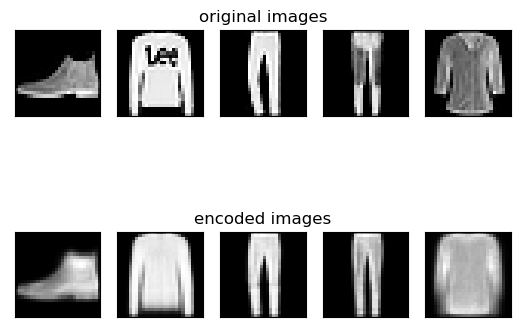

In [43]:
xhat=deep_autoencoder.predict(x_test)
plot_images(x_test,xhat,start=0,stop=5)

### Loading Images From a Directory for Autoencoders 


Loading images from a directory for Autoencoders is similar to that for neural networks, but there are also several small differences. Like neural networks we create an object using ```image_dataset_from_directory``` that consists of human faces.


In [44]:
dataset_url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/face_data.zip"
await skillsnetwork.prepare(dataset_url, overwrite=True)

  0%|          | 0/47424 [00:00<?, ?it/s]

Saved to '.'


In [45]:
img_height=50
img_width=50
batch_size=100
data_dir_face=os.path.join(os.getcwd(), 'face_data')

In [46]:
Xface = tf.keras.utils.image_dataset_from_directory(
  data_dir_face,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
    color_mode="grayscale")


Found 23708 files belonging to 1 classes.
Using 18967 files for training.


We will copy the object as we will use it multiple times 


In [47]:
X_face_copy=copy.copy(Xface)

Unlike neural networks, autoencoders have no labels. Instead, the input and output are both a set of features $\textbf{X}$. Therefore you have to map the output from the directory object from $(\textbf{x},\textbf{y})$ to $(\textbf{x},\textbf{x}$), using the following function:


In [48]:
def change_inputs(images, labels):
  
    return images, images

To apply the transform to the image, we use the ```apply``` method to apply the function ```change_inputs``` :


In [49]:
X_face_1=Xface.map(change_inputs)

We will convert the object to an iterator so we can cycle through the samples:


In [50]:
X_iter=iter(X_face_1)

We see each output is two tuples, each an array of 100 50x50 images 


In [51]:
images1, images2 = next(X_iter)

In [52]:
print("images1 shape {}, and images2 {}".format(images1.shape, images2.shape))

images1 shape (100, 50, 50, 1), and images2 (100, 50, 50, 1)


We can plot some of the images using the function ```display_auto``` where ```n``` is the sample in a batch and ```B``` is the batch number, assuming next has only been called once 


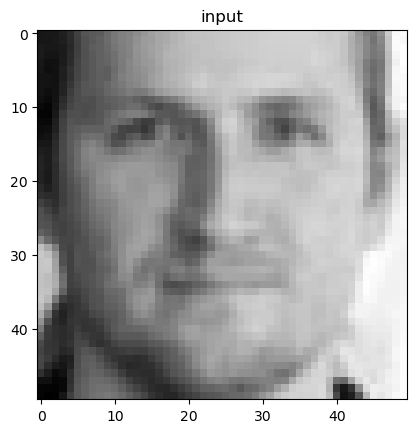

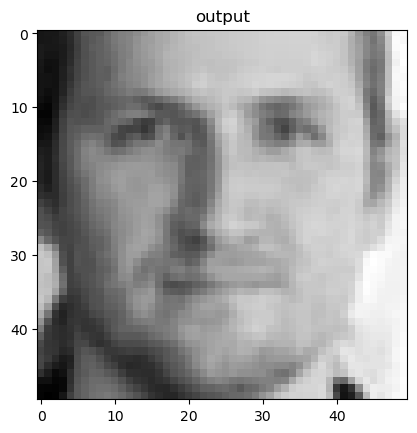

In [53]:
display_auto(X_iter,n=1,B=1)

we can also apply other transformations like normalizing the image 


In [54]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In many cases we would like a corrupted version of the image $\textbf{x},\tilde{\textbf{x}}$. Let's construct a from-the-directory object that can be used to train an autoencoder to deblur an image. In many applications like noise removal, you add noise to $\textbf{x}$ and get $\tilde{\textbf{x}}$. In this case, the input  $\tilde{\textbf{x}}$ will be a blurred image.

在许多情况下，我们希望使用图像 \$\textbf{x}\$ 的**损坏版本** \$\tilde{\textbf{x}}\$ 来进行训练。例如，在图像去噪或去模糊等应用中，我们会向原始图像 \$\textbf{x}\$ 添加噪声或模糊处理，从而得到损坏图像 \$\tilde{\textbf{x}}\$，并将其作为模型的输入。

这段话的意思是：我们将构造一个 **从目录加载图像的对象（from-the-directory object）**，这个对象将用于训练一个**自编码器（autoencoder）**，目标是**去除图像的模糊**（deblur）。在这样的任务中，输入是模糊图像 \$\tilde{\textbf{x}}\$，目标是重建出清晰的原图 \$\textbf{x}\$。

简而言之：

* \$\tilde{\textbf{x}}\$ = 模糊图像（作为输入）
* \$\textbf{x}\$ = 原始图像（作为标签）
* 我们使用一个数据生成器（如 `ImageDataGenerator`）从目录中加载图像
* 然后训练自编码器，使其能够从模糊图像中还原出清晰图像

需要构建这样一个流程来实现图像去模糊的训练。你需要我帮你写这段图像加载与模糊处理的代码吗？


In [55]:
def blur_image(images, labels):
    
    x = normalization_layer(images)
    x_b=a_conv(x)
    return x_b, x

We normalize the image and then blur the image using a filter, we apply the function to the dataset object.


In [56]:
Xface=Xface.map(blur_image)

We see the input image is blurred:


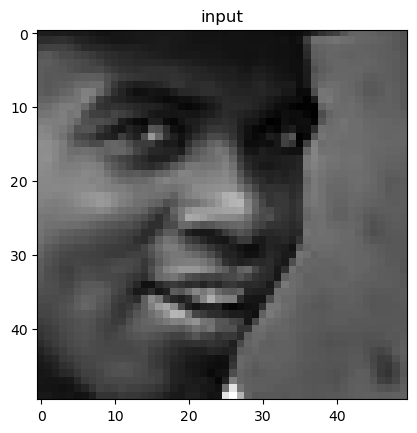

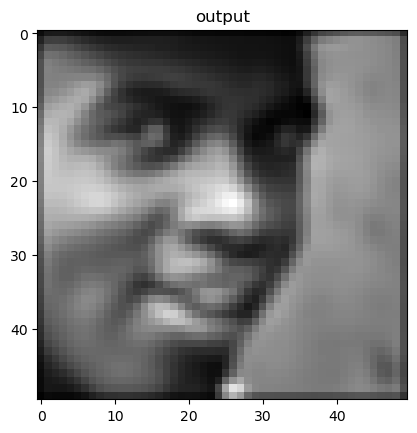

In [57]:
Xiter=iter(Xface)
display_auto(Xiter,n=1,B=1)

## Convolutional Autoencoders


Analogous to Convolutional neural networks, there are Convolutional Autoencoders (CAEs). Compared to the Autoencoders with fully connected layers, Convolutional Autoencoders with Conv2D layers do a better job encapsulating the pixel data's underlying patterns.

The following is an illustration of the CAE's architecture:

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/CAE.png" width="80%" style="vertical-align:middle;margin:15px 0px"></center>

Image from [this article](https://ai.plainenglish.io/convolutional-autoencoders-cae-with-tensorflow-97e8d8859cbe?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01). 

We can build a convolutional autoencoder class:

类比于卷积神经网络（CNN），我们也有**卷积自编码器（Convolutional Autoencoders, CAEs）**。
与使用全连接层的传统自编码器相比，**使用 `Conv2D` 卷积层的卷积自编码器在提取像素数据中潜在模式方面表现得更好**。

下面是卷积自编码器架构的示意图：

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module5/L2/CAE.png" width="80%" style="vertical-align:middle;margin:15px 0px"></center>

图片来自 [这篇文章](https://ai.plainenglish.io/convolutional-autoencoders-cae-with-tensorflow-97e8d8859cbe?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01)。




In [58]:
class CNN_Autoencoder(Model):
    def __init__(self):
        super(CNN_Autoencoder, self).__init__()
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(50, 50, 1)),
            Conv2D(16, (3, 3), activation='relu', padding='same', strides=1),
            Conv2D(8, (3, 3), activation='relu', padding='same', strides=1)])

        self.decoder = tf.keras.Sequential([
            Conv2DTranspose(8, kernel_size=3, strides=1, activation='relu', padding='same'),
            Conv2DTranspose(16, kernel_size=3, strides=1, activation='relu', padding='same'),
            Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded



The encoder consists of several convolution layers that will produce an activation map:

```encoder = tf.keras.Sequential([layers.Input(shape=(50, 50, 1)),Conv2D(16, (3, 3), activation='relu', padding='same', strides=1),Conv2D(8, (3, 3), activation='relu', padding='same', strides=1)])```


The decoder consists of several transposed convolutional or de-convolutional layers; the final layer is a convolutional layer that combines the activation maps of the previous transposed convolutional layer to form an image:

```decoder = tf.keras.Sequential([Conv2DTranspose(8, kernel_size=3, strides=1, activation='relu', padding='same'),Conv2DTranspose(16, kernel_size=3, strides=1, activation='relu', padding='same'),Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')])```


Let's create a ```CNN_Autoencoder``` object


In [59]:
cnn_autoencoder_face=CNN_Autoencoder()

Let's train the CNN autoencoder and use it to de-blur an image by minimizing the difference between $\tilde{\textbf{x}}$ and $\textbf{x}$. Note that for training, we pass in `Xface`, which can be seen as an image data generator that will feed our model pairs of blurred images and original image. We expect the model to learn and minimize the difference between the two and eventually be able to recover the original image from a blurred image.


Epoch 1/10
190/190 [==============================] - 62s 316ms/step - loss: 0.0119
Epoch 2/10
190/190 [==============================] - 59s 306ms/step - loss: 0.0026
Epoch 3/10
190/190 [==============================] - 60s 313ms/step - loss: 0.0019
Epoch 4/10
190/190 [==============================] - 60s 311ms/step - loss: 0.0016
Epoch 5/10
190/190 [==============================] - 58s 302ms/step - loss: 0.0014
Epoch 6/10
190/190 [==============================] - 57s 299ms/step - loss: 0.0013
Epoch 7/10
190/190 [==============================] - 59s 306ms/step - loss: 0.0012
Epoch 8/10
190/190 [==============================] - 57s 298ms/step - loss: 0.0012
Epoch 9/10
190/190 [==============================] - 59s 310ms/step - loss: 0.0011
Epoch 10/10
190/190 [==============================] - 60s 315ms/step - loss: 0.0011


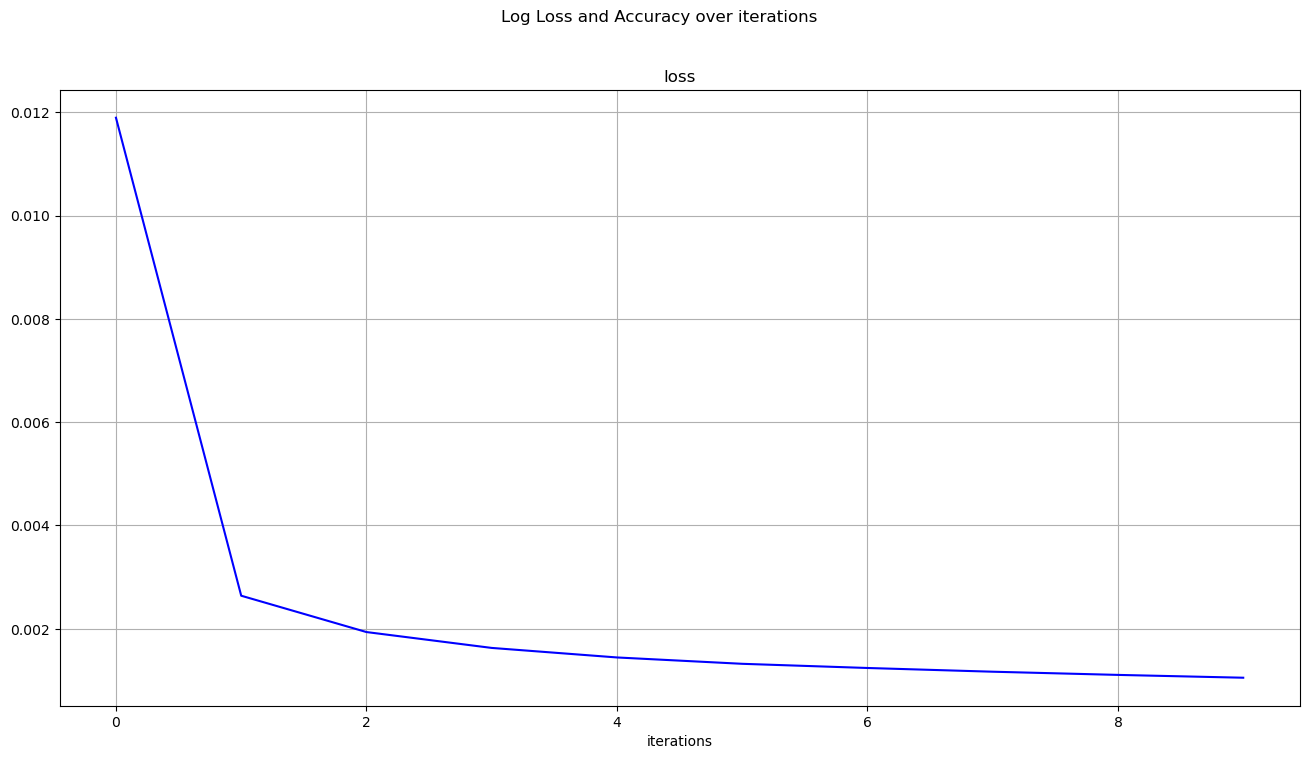

In [60]:
cnn_autoencoder_face.compile(optimizer='adam',  loss='mse')
history=cnn_autoencoder_face.fit(Xface,epochs=10)

graph_history(history, title='Log Loss and Accuracy over iterations')


We take some samples from the set of blurred images and use the trained autoencoder to deblur the images and compare them to the blurred images.


In [61]:
x = next(Xiter)
Xhat=cnn_autoencoder_face.predict(x[0])

4/4 [==============================] - 0s 27ms/step


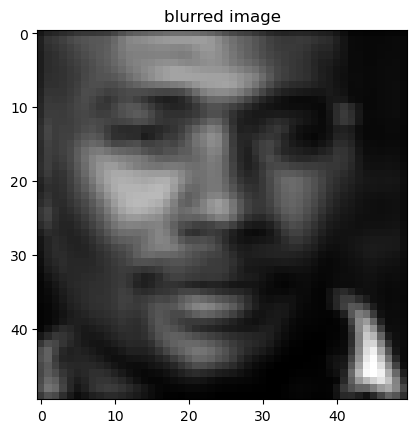

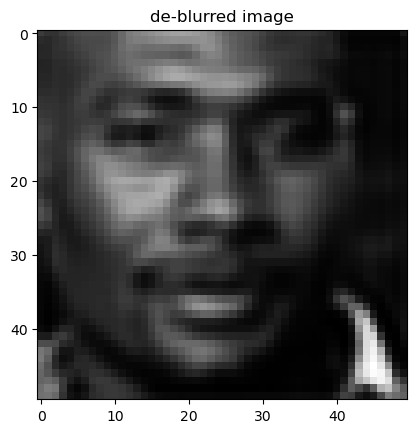

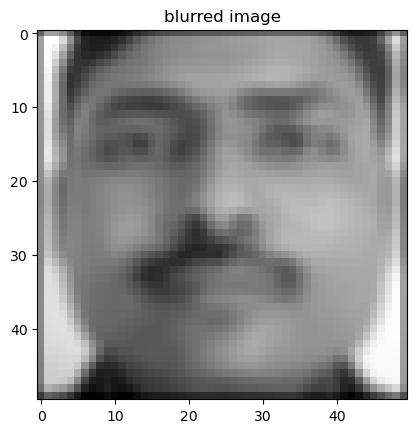

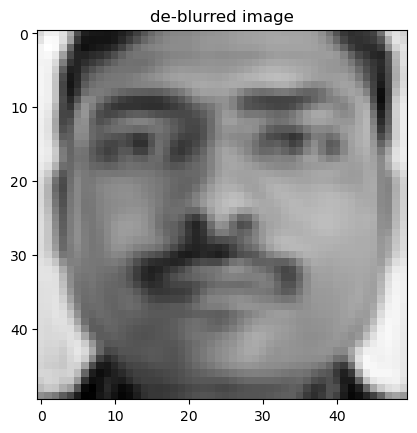

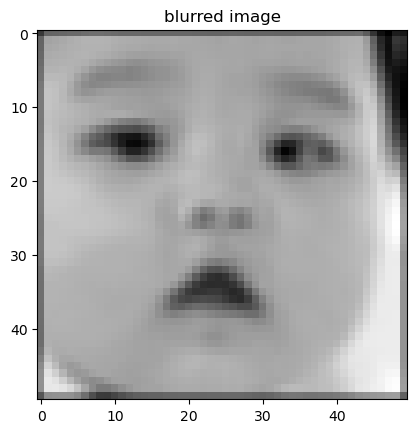

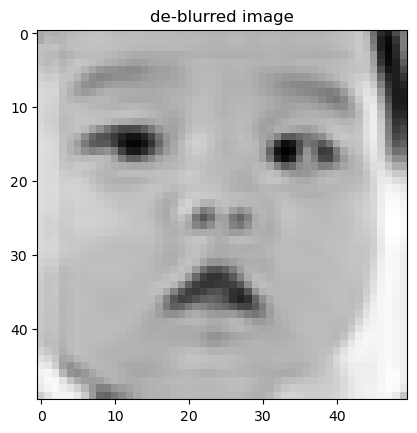

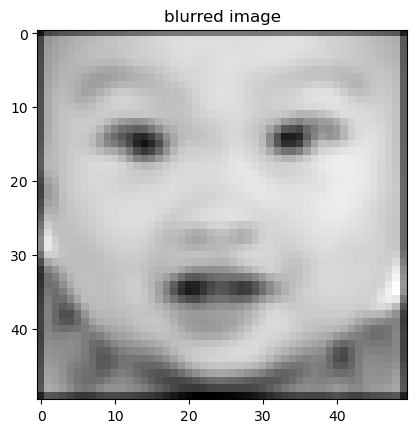

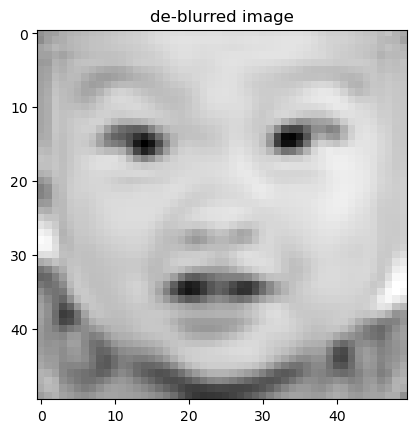

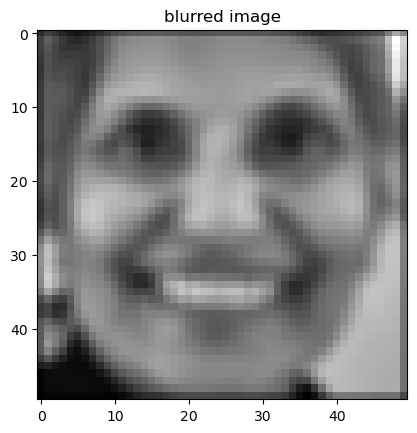

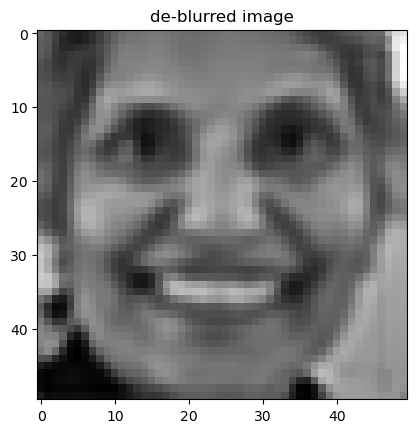

In [62]:
for image_b, image_db in zip(x[0].numpy()[0:5,:,:,0],Xhat[0:5,:,:,0]):
    plt.imshow(image_b, cmap="gray")
    plt.title("blurred image")
    plt.show()
    plt.imshow(image_db, cmap="gray")
    plt.title("de-blurred image")
    plt.show()

We see that as the CNN autoencoder can learn the complex image features well, it can be used to de-blur the blurred images and represent the features more clearly.


## Congratulations! You've completed the exercises. 


## Author


<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


[Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01) is a Data Science intern at IBM Skills Network, entering level-5 study in the Mathematics & Statistics undergraduate Coop program at McMaster University.


## Change Log

| Date (YYYY-MM-DD) | Version | Changed By | Change Description                 |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 2022-03-28        | 0.1     | David Pasternak      | Created Lab    |
| 2022-05-10        | 0.2     | Sam Prokopchuk      | Complete Draft of Lab    |
| 2022-08-05        | 0.3     | Roxanne Li      | Review and edit Lab    |
| 2022-09-09        | 0.3     | Steve Hord      | QA pass edits          |

## <h3 align="center"> © IBM Corporation 2022. All rights reserved. <h3/>
